downloads moroccan stock prices dataset from kaggle

In [51]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aymanlafaz/moroccan-stock-prices")

print("Path to dataset files:", path)

Path to dataset files: /Users/mac/.cache/kagglehub/datasets/aymanlafaz/moroccan-stock-prices/versions/1


In [52]:
import pandas as pd

df = pd.read_csv(path+"/stocks.csv")
prices = df["MASI"].values.reshape((-1, 1))

In [53]:
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Compute log-returns
log_returns = []
for i in range(1, len(prices)):
    log_returns.append(math.log(prices[i] / prices[i-1]))

log_returns = np.array(log_returns).reshape(-1, 1)  


/var/folders/y2/whflsc057l59px222k3zxmxm0000gn/T/ipykernel_85129/1583953412.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log_returns.append(math.log(prices[i] / prices[i-1]))


In [ ]:
import numpy as np

#how many days we will use to predict the next day
timesteps = 3


#we prepare inputs by adding "timsteps" prior to each day
X, Y = [], []

for i in range(timesteps, len(log_returns)):
    X.append(log_returns[i-timesteps:i])
    Y.append(log_returns[i])

X, Y = np.array(X), np.array(Y)

X = X.reshape(X.shape[0], X.shape[1], 1)


#we split data for training and testing
train_size = int(0.8 * len(X))
                 
X_train = X[:train_size]
Y_train = Y[:train_size]

X_eval = X[train_size:]
Y_eval = Y[train_size:]


In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam


ltsm_model = Sequential([
    layers.Input((timesteps, 1)),
    layers.LSTM(60),
    layers.Dense(30, activation = "relu"),
    layers.Dense(30, activation = "relu"),
    layers.Dense(1)
])


ltsm_model.compile(loss = "mse", optimizer=Adam(learning_rate = 0.001), metrics=['mean_absolute_error'])
ltsm_model.fit(X_train, Y_train, epochs=100, validation_data=(X_eval, Y_eval))


Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 6.3096e-05 - mean_absolute_error: 0.0049 - val_loss: 3.5032e-05 - val_mean_absolute_error: 0.0047
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.0795e-05 - mean_absolute_error: 0.0051 - val_loss: 1.8832e-05 - val_mean_absolute_error: 0.0033
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.7932e-05 - mean_absolute_error: 0.0047 - val_loss: 2.1401e-05 - val_mean_absolute_error: 0.0036
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.6825e-05 - mean_absolute_error: 0.0049 - val_loss: 1.9144e-05 - val_mean_absolute_error: 0.0033
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 9.5131e-05 - mean_absolute_error: 0.0053 - val_loss: 1.9465e-05 - val_mean_absolute_error: 0.0033
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6.0781e-05 - mean_absolute_error: 0.0050 - val_loss: 2.1218e-05 - val_mean_absolute_error: 0.0034
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step 

In [68]:
feed_forward_model = Sequential([
    layers.Input((timesteps,)),
    layers.Dense(30, activation = "relu"),
    layers.Dense(30, activation = "relu"),
    layers.Dense(1)
])


feed_forward_model.compile(loss = "mse", optimizer=Adam(learning_rate = 0.001), metrics=['mean_absolute_error'])
feed_forward_model.fit(X_train.reshape(-1, 3), Y_train, epochs=100, validation_data=(X_eval, Y_eval))

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 7.8233e-05 - mean_absolute_error: 0.0051 - val_loss: 2.0077e-05 - val_mean_absolute_error: 0.0035
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.8002e-05 - mean_absolute_error: 0.0048 - val_loss: 1.9361e-05 - val_mean_absolute_error: 0.0034
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.5352e-05 - mean_absolute_error: 0.0046 - val_loss: 1.9506e-05 - val_mean_absolute_error: 0.0034
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.2992e-05 - mean_absolute_error: 0.0050 - val_loss: 1.8767e-05 - val_mean_absolute_error: 0.0033
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.4464e-05 - mean_absolute_error: 0.0047 - val_loss: 1.9219e-05 - val_mean_absolute_error: 0.0033
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.5079e-05 - mean_absolute_error: 0.0047 - val_loss: 1.9476e-05 - val_mean_absolute_error: 0.0034
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - l

In [57]:
cnn_model = Sequential([
    layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(timesteps, 1)),
    layers.Flatten(),
    layers.Dense(30, activation="relu"),
    layers.Dense(30, activation="relu"),
    layers.Dense(1)
])


cnn_model.compile(loss = "mse", optimizer=Adam(learning_rate = 0.001), metrics=['mean_absolute_error'])
cnn_model.fit(X_train, Y_train, epochs=100, validation_data=(X_eval, Y_eval))

Epoch 1/100


/Users/mac/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 8.1493e-05 - mean_absolute_error: 0.0054 - val_loss: 2.0714e-05 - val_mean_absolute_error: 0.0034
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.5333e-05 - mean_absolute_error: 0.0046 - val_loss: 2.0094e-05 - val_mean_absolute_error: 0.0034
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.8404e-05 - mean_absolute_error: 0.0048 - val_loss: 1.9332e-05 - val_mean_absolute_error: 0.0034
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.8902e-05 - mean_absolute_error: 0.0045 - val_loss: 1.8801e-05 - val_mean_absolute_error: 0.0033
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.7778e-05 - mean_absolute_error: 0.0050 - val_loss: 1.8738e-05 - val_mean_absolute_error: 0.0033
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.4197e-05 - mean_absolute_error: 0.0051 - val_loss: 1.9480e-05 - val_mean_absolute_error: 0.0033
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.60

In [70]:
ltsm_model.save('lstm_morrocan_stock_model.h5')
feed_forward_model.save('feed_forward_stock_model.h5')
cnn_model.save('cnn_stock_model.h5')

In [71]:
def convertToPrices(log_returns):
    res = [0]

    for i in range(1, len(log_returns)):
        res.append(prices[i-1][0]*math.exp(log_returns[i]))

    return res

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


/var/folders/y2/whflsc057l59px222k3zxmxm0000gn/T/ipykernel_85129/1500671237.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res.append(prices[i-1][0]*math.exp(log_returns[i]))


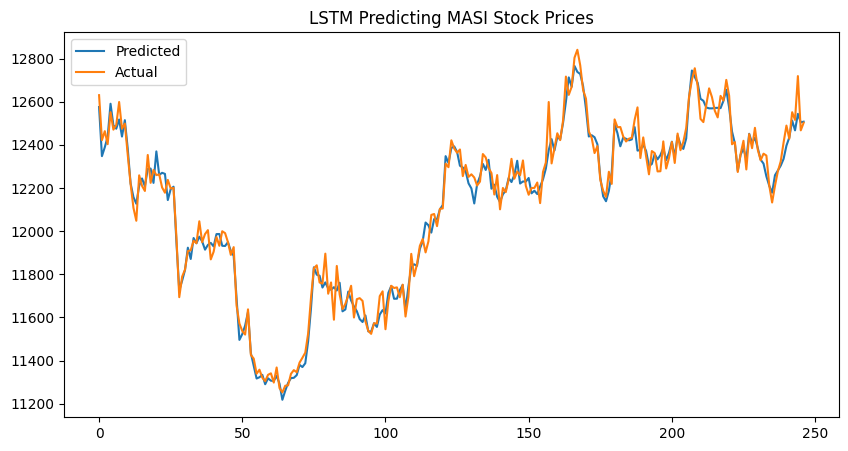

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


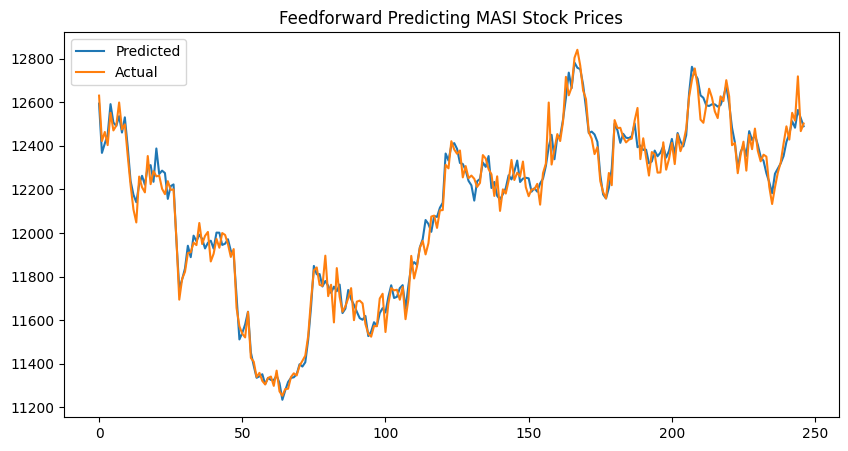

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


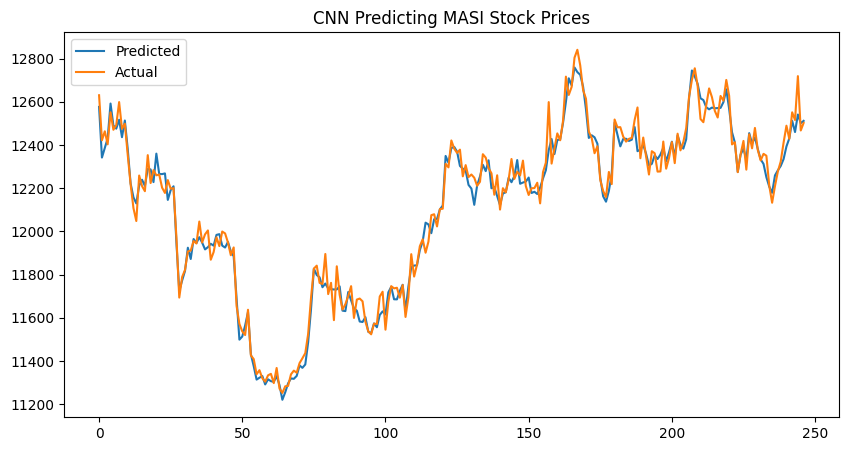

In [72]:
import matplotlib.pyplot as plt

actual_prices = convertToPrices(Y_eval)

# --- LSTM Model ---
ltsm_test_predictions = ltsm_model.predict(X_eval).flatten()
predicted_prices = convertToPrices(ltsm_test_predictions)

plt.figure(figsize=(10, 5))
plt.plot(predicted_prices[1:], label='Predicted')
plt.plot(actual_prices[1:], label='Actual')
plt.title("LSTM Predicting MASI Stock Prices")
plt.legend()
plt.show()


# --- Feedforward Model ---
feed_forward_test_predictions = feed_forward_model.predict(X_eval).flatten()
predicted_prices = convertToPrices(feed_forward_test_predictions)

plt.figure(figsize=(10, 5))
plt.plot(predicted_prices[1:], label='Predicted')
plt.plot(actual_prices[1:], label='Actual')
plt.title("Feedforward Predicting MASI Stock Prices")
plt.legend()
plt.show()


# --- CNN Model ---
cnn_test_predictions = cnn_model.predict(X_eval).flatten()
predicted_prices = convertToPrices(cnn_test_predictions)

plt.figure(figsize=(10, 5))
plt.plot(predicted_prices[1:], label='Predicted')
plt.plot(actual_prices[1:], label='Actual')
plt.title("CNN Predicting MASI Stock Prices")
plt.legend()
plt.show()
